In [1]:
import pandas as pd
from scipy import stats
import sys
sys.path.append('../src')
from enrich import enrich_listings

df = enrich_listings()
df_valid = df[(df['price_outlier_flag']==False) & (df['price_clean'].notna())]

entire = df_valid[df_valid['room_type']=='Entire home/apt']['price_clean']
private = df_valid[df_valid['room_type']=='Private room']['price_clean']

print(f"Entire home: n={len(entire)}, mean={entire.mean():.2f}, std={entire.std():.2f}")
print(f"Private room: n={len(private)}, mean={private.mean():.2f}, std={private.std():.2f}")

# Check normality assumption first
print(stats.shapiro(entire.sample(min(5000, len(entire)), random_state=42)))
print(stats.shapiro(private.sample(min(5000, len(private)), random_state=42)))

Loaded listings: 10480 rows, 79 columns
Price cleaned. Outliers flagged: 7

Date parsing check:
   host_since host_since_parsed
0  2010-03-23        2010-03-23
1  2010-05-13        2010-05-13
2  2010-05-13        2010-05-13
3  2010-08-08        2010-08-08
4  2010-09-01        2010-09-01

Unparseable dates per column:
  last_scraped: 0 unparseable (out of 10480 non-null originals)
  first_review: 1097 unparseable (out of 9383 non-null originals)
  last_review: 1097 unparseable (out of 9383 non-null originals)
  host_since: 3 unparseable (out of 10477 non-null originals)

Property type grouping:
property_type_grouped
Entire place      8214
Private room      1371
Hotel room         418
Houseboat/Boat     392
Other               30
Shared room         29
Room in other       26
Name: count, dtype: int64

Columns after dropping unreliable ones: 85
Missing flags: beds=4576, bathrooms=4548, price=4606

Coordinate precision after standardization:
latitude
5    9349
4    1019
3     105
2       7

In [2]:
u_stat, p_value = stats.mannwhitneyu(entire, private, alternative='two-sided')
print(f"U statistic: {u_stat}")
print(f"p-value: {p_value}")

# Effect size: rank-biserial correlation (appropriate for Mann-Whitney)
n1, n2 = len(entire), len(private)
r = 1 - (2*u_stat) / (n1 * n2)
print(f"Rank-biserial correlation (effect size): {r:.4f}")

U statistic: 4680826.5
p-value: 4.953350071257756e-253
Rank-biserial correlation (effect size): -0.6221


In [ ]:
##-----------------H2 : Superhost vs. Non-Superhost Review Scores-------------------------
superhost_scores = df[df['host_is_superhost']=='t']['review_scores_rating'].dropna()
non_superhost_scores = df[df['host_is_superhost']=='f']['review_scores_rating'].dropna()

print(stats.shapiro(superhost_scores.sample(min(5000, len(superhost_scores)), random_state=42)))
print(stats.shapiro(non_superhost_scores.sample(min(5000, len(non_superhost_scores)), random_state=42)))
print(f"Superhost: n={len(superhost_scores)}, mean={superhost_scores.mean():.3f}")
print(f"Non-superhost: n={len(non_superhost_scores)}, mean={non_superhost_scores.mean():.3f}")

ShapiroResult(statistic=np.float64(0.6172392769729891), pvalue=np.float64(5.192255589434924e-53))
ShapiroResult(statistic=np.float64(0.5932040804608053), pvalue=np.float64(9.427460660625239e-76))
Superhost: n=1813, mean=4.865
Non-superhost: n=7460, mean=4.839


In [4]:
u_stat2, p_value2 = stats.mannwhitneyu(superhost_scores, non_superhost_scores, alternative='two-sided')
n1, n2 = len(superhost_scores), len(non_superhost_scores)
r2 = 1 - (2*u_stat2) / (n1 * n2)

print(f"U statistic: {u_stat2}")
print(f"p-value: {p_value2}")
print(f"Rank-biserial correlation (effect size): {r2:.4f}")

U statistic: 5894053.0
p-value: 2.0135998888920313e-18
Rank-biserial correlation (effect size): 0.1284


In [ ]:
##----H3 : Listings with >10 reviews vs. ≤10 reviews, price difference--------
high_reviews = df_valid[df_valid['review_count_computed'] > 10]['price_clean']
low_reviews = df_valid[df_valid['review_count_computed'] <= 10]['price_clean']

print(stats.shapiro(high_reviews.sample(min(5000, len(high_reviews)), random_state=42)))
print(stats.shapiro(low_reviews.sample(min(5000, len(low_reviews)), random_state=42)))
print(f">10 reviews: n={len(high_reviews)}, mean={high_reviews.mean():.2f}")
print(f"<=10 reviews: n={len(low_reviews)}, mean={low_reviews.mean():.2f}")

ShapiroResult(statistic=np.float64(0.2970516342034646), pvalue=np.float64(1.4283564879305937e-75))
ShapiroResult(statistic=np.float64(0.21552478565566846), pvalue=np.float64(6.893019874040519e-76))
>10 reviews: n=3054, mean=257.32
<=10 reviews: n=2813, mean=288.79


In [6]:
u_stat3, p_value3 = stats.mannwhitneyu(high_reviews, low_reviews, alternative='two-sided')
n1, n2 = len(high_reviews), len(low_reviews)
r3 = 1 - (2*u_stat3) / (n1 * n2)

print(f"U statistic: {u_stat3}")
print(f"p-value: {p_value3}")
print(f"Rank-biserial correlation (effect size): {r3:.4f}")

U statistic: 3627805.5
p-value: 6.975502511547606e-25
Rank-biserial correlation (effect size): 0.1554


In [ ]:
##---H4 : Neighbourhood Price Differences (ANOVA)----------------
neighbourhood_groups = [group['price_clean'].dropna().values 
                          for name, group in df_valid.groupby('neighbourhood_cleansed')]

# Check homogeneity of variance (Levene's test) - an ANOVA assumption
levene_stat, levene_p = stats.levene(*neighbourhood_groups)
print(f"Levene's test: statistic={levene_stat:.4f}, p-value={levene_p}")

Levene's test: statistic=3.4195, p-value=2.025219661302865e-07


In [8]:
h_stat, p_value4 = stats.kruskal(*neighbourhood_groups)
print(f"H statistic: {h_stat:.4f}")
print(f"p-value: {p_value4}")

# Effect size for Kruskal-Wallis: eta-squared approximation
n_total = sum(len(g) for g in neighbourhood_groups)
k_groups = len(neighbourhood_groups)
eta_squared = (h_stat - k_groups + 1) / (n_total - k_groups)
print(f"Eta-squared (effect size): {eta_squared:.4f}")

H statistic: 417.2274
p-value: 2.5105639011629185e-75
Eta-squared (effect size): 0.0678


In [ ]:
##-----5.2
def compute_ci(data, confidence=0.95):
    n = len(data)
    mean = data.mean()
    sem = stats.sem(data)
    ci = stats.t.interval(confidence, n-1, loc=mean, scale=sem)
    return mean, ci

for room_type in ['Entire home/apt', 'Private room', 'Hotel room', 'Shared room']:
    data = df_valid[df_valid['room_type']==room_type]['price_clean']
    mean, ci = compute_ci(data)
    print(f"{room_type}: n={len(data)}, mean=€{mean:.2f}, 95% CI=[€{ci[0]:.2f}, €{ci[1]:.2f}]")

Entire home/apt: n=4530, mean=€301.00, 95% CI=[€290.23, €311.78]
Private room: n=1274, mean=€175.73, 95% CI=[€157.19, €194.26]
Hotel room: n=33, mean=€209.30, 95% CI=[€169.80, €248.80]
Shared room: n=30, mean=€130.27, 95% CI=[€90.69, €169.84]


In [10]:
top_5_neighbourhoods = df_valid['neighbourhood_cleansed'].value_counts().head(5).index

for n_hood in top_5_neighbourhoods:
    data = df_valid[df_valid['neighbourhood_cleansed']==n_hood]['price_clean']
    mean, ci = compute_ci(data)
    print(f"{n_hood}: n={len(data)}, mean=€{mean:.2f}, 95% CI=[€{ci[0]:.2f}, €{ci[1]:.2f}]")

De Baarsjes - Oud-West: n=992, mean=€271.28, 95% CI=[€262.31, €280.25]
Centrum-West: n=770, mean=€315.88, 95% CI=[€285.46, €346.30]
De Pijp - Rivierenbuurt: n=649, mean=€280.47, 95% CI=[€268.70, €292.23]
Centrum-Oost: n=580, mean=€307.72, 95% CI=[€281.21, €334.24]
Zuid: n=435, mean=€309.58, 95% CI=[€282.36, €336.81]


In [ ]:
##-------------------Cohen's d for H1-------------------------
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    pooled_std = ((n1-1)*group1.std()**2 + (n2-1)*group2.std()**2) / (n1+n2-2)
    pooled_std = pooled_std**0.5
    return (group1.mean() - group2.mean()) / pooled_std

d = cohens_d(entire, private)
print(f"Cohen's d: {d:.4f}")

Cohen's d: 0.3451


In [12]:
numeric_cols = ['price_clean', 'accommodates', 'bedrooms', 'beds', 'review_scores_rating',
                 'availability_365', 'review_count_computed', 'occupancy_rate_calculated',
                 'host_tenure_years', 'minimum_nights']

corr_matrix = df_valid[numeric_cols].corr()
print(corr_matrix['price_clean'].sort_values(ascending=False))

price_clean                  1.000000
bedrooms                     0.272633
accommodates                 0.270875
beds                         0.233710
availability_365             0.088690
review_scores_rating         0.038011
host_tenure_years           -0.002927
minimum_nights              -0.022351
review_count_computed       -0.087645
occupancy_rate_calculated   -0.089092
Name: price_clean, dtype: float64


In [14]:
pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 466.4 kB/s eta 0:00:20
   -- ------------------------------------- 0.5/9.6 MB 466.4 kB/s eta 0:00:20
   -- ------------------------------------- 0.5/9.6 MB 466.4 kB/s eta 0:00:20
   -- ------------------------------------- 0.5/9.6 MB 466.4 kB/s eta 0:00:20
   -- ------------------------------------- 0.5/9.6 MB 466.4 kB/s eta 0:00:20
   -- ------------------------------------- 0.5/9.6 MB 466.4 kB/s eta 0:00:20
   -- ------------------------------------- 0.5/9.6 MB 466.4 kB/s eta 0:00:20
   -- ------------------------------------- 0.5/9.6 MB 466.4 kB/s eta 0:00:20
   -- -------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import statsmodels.api as sm

reg_df = df_valid[['price_clean', 'accommodates', 'bedrooms', 'beds', 
                     'review_scores_rating', 'availability_365', 
                     'review_count_computed', 'host_tenure_years']].dropna()

X = reg_df.drop(columns=['price_clean'])
X = sm.add_constant(X)
y = reg_df['price_clean']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            price_clean   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     78.65
Date:                Sun, 21 Jun 2026   Prob (F-statistic):          6.86e-109
Time:                        11:31:32   Log-Likelihood:                -36789.
No. Observations:                5203   AIC:                         7.359e+04
Df Residuals:                    5195   BIC:                         7.365e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  -156.96

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

                 feature         VIF
0                  const  372.715732
1           accommodates    3.186831
2               bedrooms    2.444773
3                   beds    2.872567
4   review_scores_rating    1.038972
5       availability_365    1.046396
6  review_count_computed    1.064092
7      host_tenure_years    1.057740


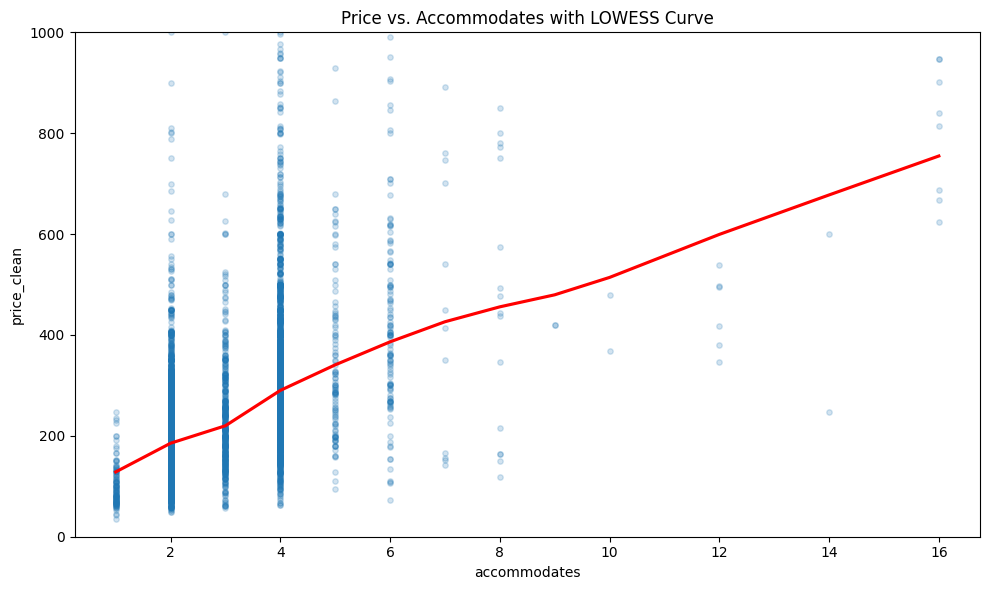

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.regplot(data=reg_df, x='accommodates', y='price_clean', lowess=True, 
            scatter_kws={'alpha':0.2, 's':15}, line_kws={'color':'red'})
plt.ylim(0, 1000)
plt.title('Price vs. Accommodates with LOWESS Curve')
plt.tight_layout()
plt.savefig('../reports/price_vs_accommodates_lowess.png', dpi=150)
plt.show()